# Deadtime estimates (channel threshold)

Project 2D (channels, windows) into 1D using `x = channels * windows`, then fit `deadtime = m*x + b`.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
from scipy.optimize import least_squares

sns.set_context('talk')

ROOT = Path.cwd().resolve().parent
EST_PATH = ROOT / 'data' / 'estimated_deadtime_10hz-12-24-25_full_channels.json'

with EST_PATH.open() as fh:
    estimates = json.load(fh)
est_df = pd.DataFrame(estimates)

print('Rows:', len(est_df))
print('Pulse rates:', sorted(est_df['pulse_rate_hz'].dropna().unique()))
print('Pulse counts:', sorted(est_df['num_pulses'].dropna().unique()))


Rows: 91
Pulse rates: [10.0]
Pulse counts: [2]


## Linear fit on projected axis


m = 1.346664 ± 0.001604 us per (channels*windows)
b = 2.894410 ± 0.294960 us
chi2 = 5272276.72, dof = 89, chi2/dof = 59239.06, p = 0


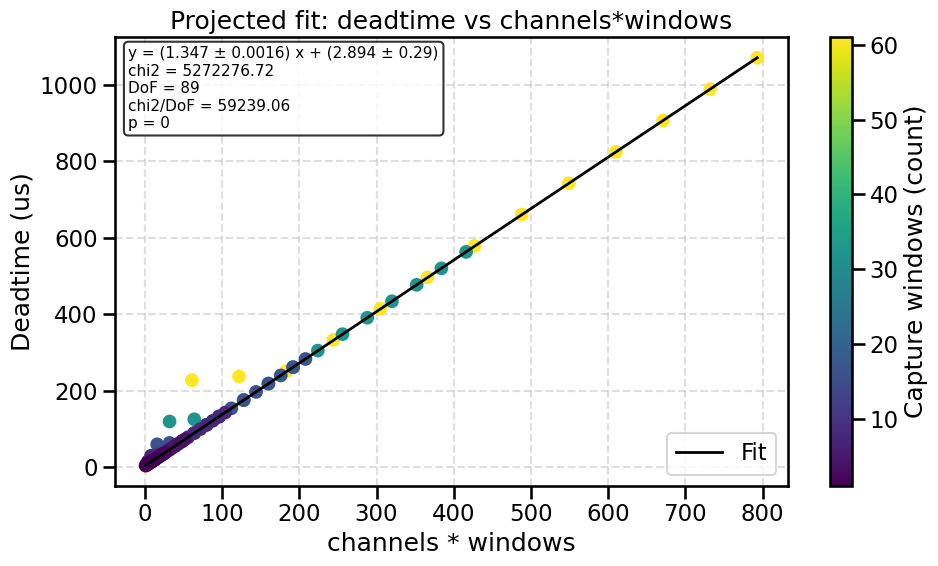

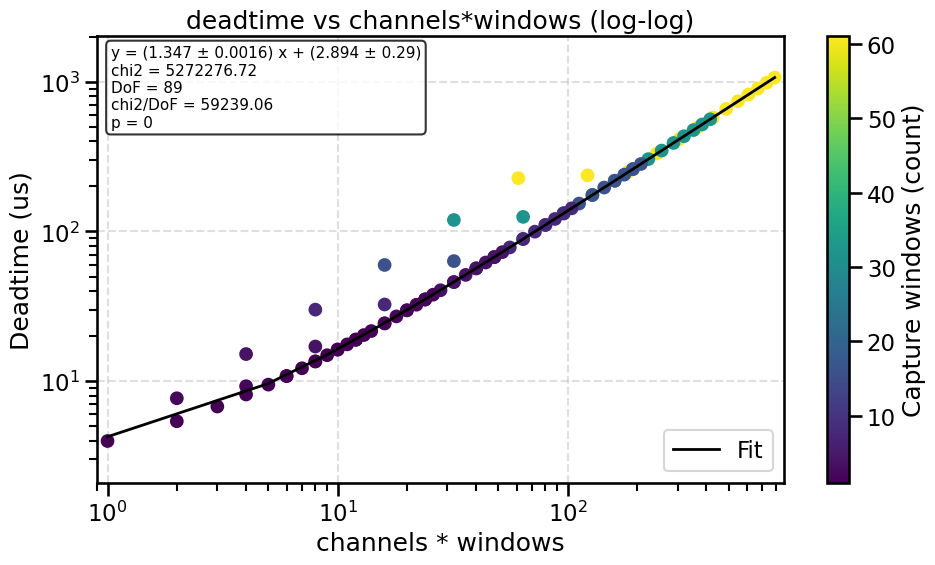

In [2]:
df = est_df.copy()
df = df.dropna(subset=['channel_count', 'windows', 'min_all_pulses_response_us'])
df = df[df['all_pulses_observed'] == True]

df['x'] = df['channel_count'] * df['windows']
df['y'] = df['min_all_pulses_response_us']
df['yerr_low'] = df['min_all_pulses_response_us'] - df['min_all_pulses_lower_bound_us']
df = df.dropna(subset=['yerr_low'])
df = df[df['yerr_low'] > 0]

x = df['x'].to_numpy(dtype=float)
y = df['y'].to_numpy(dtype=float)
yerr_low = df['yerr_low'].to_numpy(dtype=float)
yerr_high = np.full_like(y, 0.008)

def fit_asymmetric(x_vals, y_vals, err_low, err_high):
    def residuals(params):
        m, b = params
        resid = y_vals - (m * x_vals + b)
        sigma = np.where(resid >= 0, err_low, err_high)
        return resid / sigma

    m0, b0 = np.polyfit(x_vals, y_vals, 1)
    result = least_squares(residuals, x0=np.array([m0, b0]))
    m, b = result.x
    resid = y_vals - (m * x_vals + b)
    sigma = np.where(resid >= 0, err_low, err_high)
    chi2_val = np.sum((resid / sigma) ** 2)
    dof = len(y_vals) - 2
    p_val = chi2.sf(chi2_val, dof) if dof > 0 else float('nan')
    m_err = float('nan')
    b_err = float('nan')
    if result.jac.shape[0] >= result.jac.shape[1]:
        try:
            cov = np.linalg.inv(result.jac.T @ result.jac)
            if dof > 0:
                cov = cov * (chi2_val / dof)
            m_err, b_err = np.sqrt(np.diag(cov))
        except np.linalg.LinAlgError:
            pass
    return m, b, m_err, b_err, chi2_val, dof, p_val

m, b, m_err, b_err, chi2_val, dof, p_val = fit_asymmetric(x, y, yerr_low, yerr_high)
y_fit = m * x + b

print(f'm = {m:.6f} ± {m_err:.6f} us per (channels*windows)')
print(f'b = {b:.6f} ± {b_err:.6f} us')
print(f'chi2 = {chi2_val:.2f}, dof = {dof}, chi2/dof = {chi2_val / dof:.2f}, p = {p_val:.3g}')

plt.figure(figsize=(10, 6))
ax = plt.gca()
stats_text = (
    f'y = ({m:.4g} ± {m_err:.2g}) x + ({b:.4g} ± {b_err:.2g})\n'
    f'chi2 = {chi2_val:.2f}\nDoF = {dof}\nchi2/DoF = {chi2_val / dof:.2f}\np = {p_val:.3g}'
)
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, ha='left', va='top', fontsize=11, bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.8})

plt.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt='none', ecolor='gray', alpha=0.5, zorder=1)
sc = plt.scatter(x, y, c=df['windows'], cmap='viridis', s=70, zorder=2)
x_line = np.linspace(x.min(), x.max(), 200)
plt.plot(x_line, m * x_line + b, color='black', linewidth=2, label='Fit')
cbar = plt.colorbar(sc)
cbar.set_label('Capture windows (count)')
plt.title('Projected fit: deadtime vs channels*windows')
plt.xlabel('channels * windows')
plt.ylabel('Deadtime (us)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Log-scale plot
plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, ha='left', va='top', fontsize=11, bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.8})
plt.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt='none', ecolor='gray', alpha=0.5, zorder=1)
sc = plt.scatter(x, y, c=df['windows'], cmap='viridis', s=70, zorder=2)
plt.plot(x_line, m * x_line + b, color='black', linewidth=2, label='Fit')
cbar = plt.colorbar(sc)
cbar.set_label('Capture windows (count)')
plt.xscale('log')
plt.yscale('log')
x_min, x_max = x.min() * 0.9, x.max() * 1.1
y_min, y_max = y.min() * 0.9, y.max() * 1.1
lx_min, lx_max = np.log10(x_min), np.log10(x_max)
ly_min, ly_max = np.log10(y_min), np.log10(y_max)
span = max(lx_max - lx_min, ly_max - ly_min)
lx_center = 0.5 * (lx_min + lx_max)
ly_center = 0.5 * (ly_min + ly_max)
ax.set_xlim(10 ** (lx_center - span / 2), 10 ** (lx_center + span / 2))
ax.set_ylim(10 ** (ly_center - span / 2), 10 ** (ly_center + span / 2))
plt.title('deadtime vs channels*windows (log-log)')
plt.xlabel('channels * windows')
plt.ylabel('Deadtime (us)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='lower right')
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.tight_layout()
plt.show()


## Digitization + congestion fit

Fit a three-parameter model `y = a + b*windows + c*(channels*windows)` to the full dataset, then show per-channel curves on the windows axis with goodness-of-fit stats printed below the plot and legends outside the axes.

Global fit: y = a + b*windows + c*(channels*windows)
 a = 2.661663 ± 0.524604 us (baseline)
 b = 0.093157 ± 0.037689 us per window (digitization)
 c = 1.334119 ± 0.006793 us per (channel*window) (congestion)
 chi2 = 4893118.53, dof = 88, chi2/dof = 55603.62, p = 0


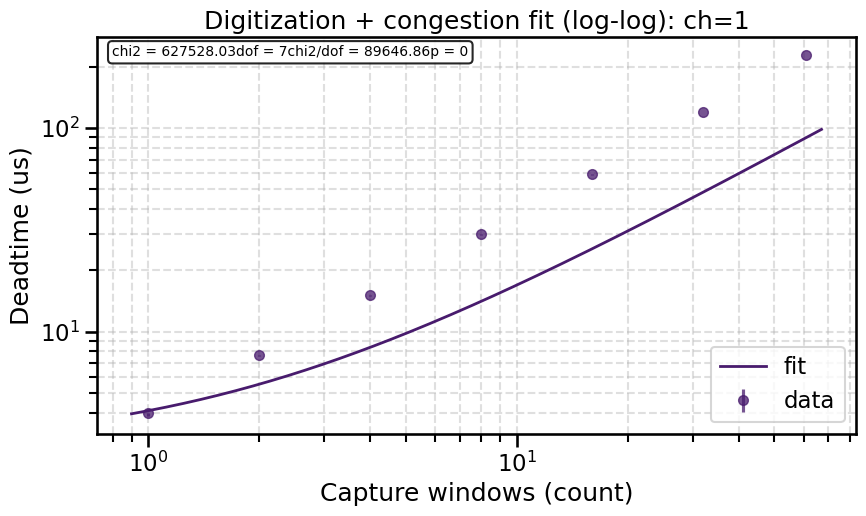

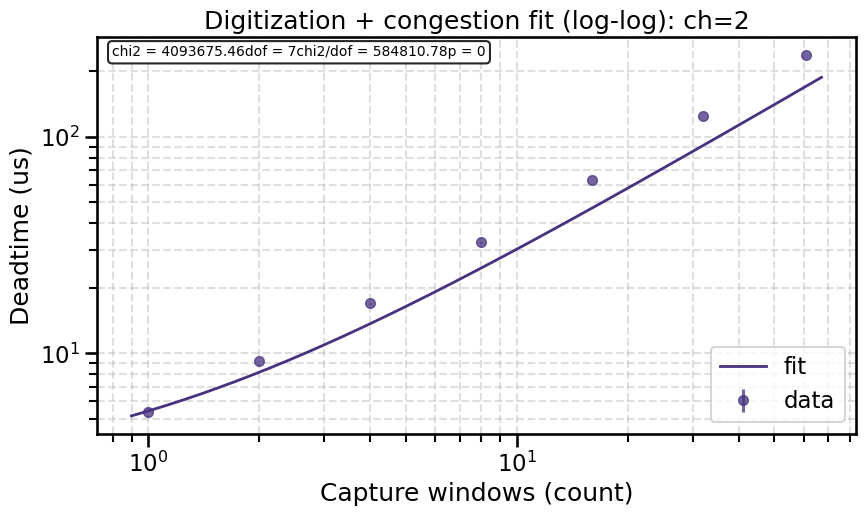

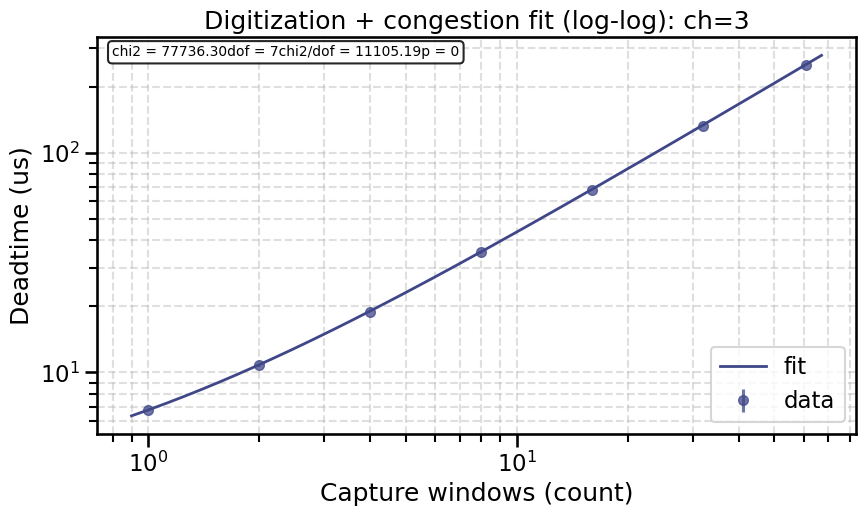

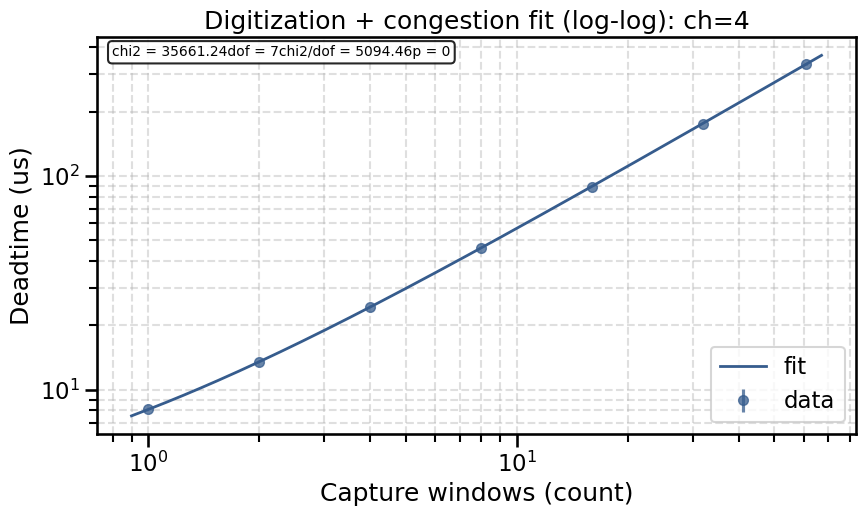

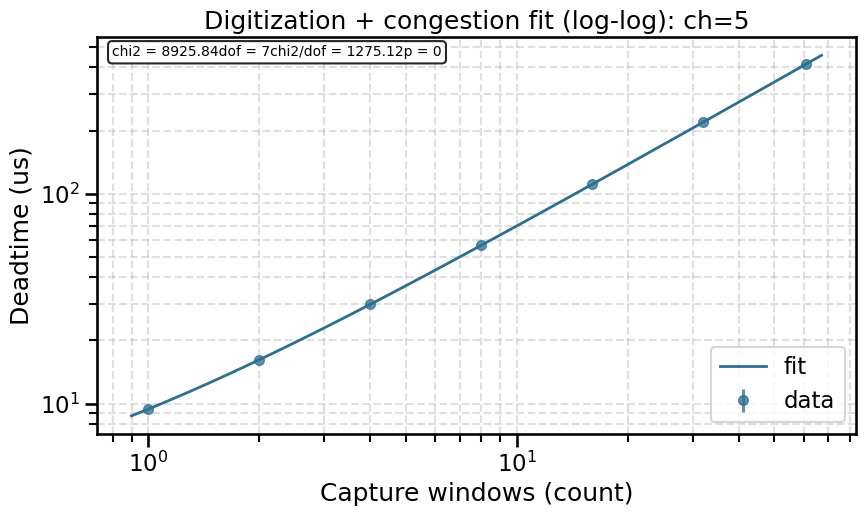

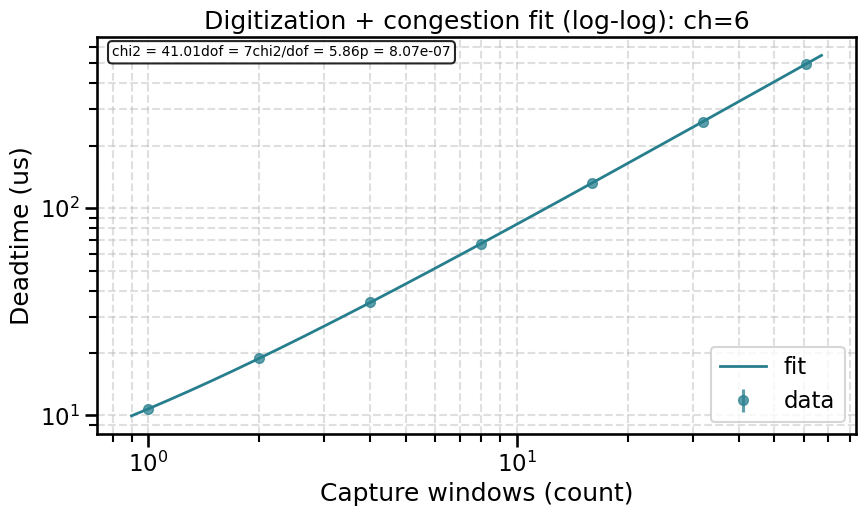

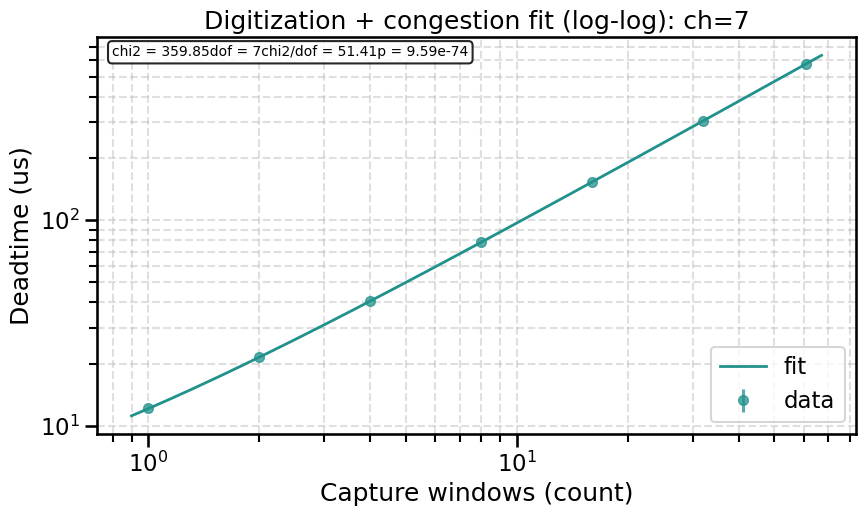

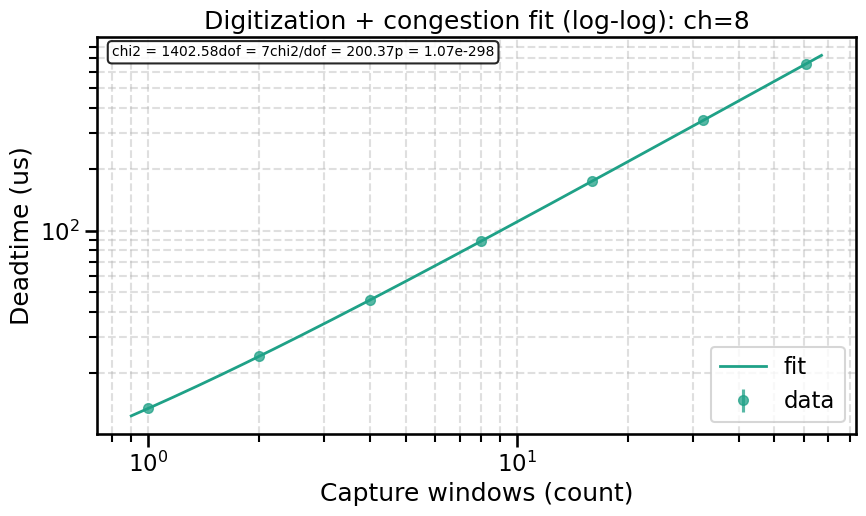

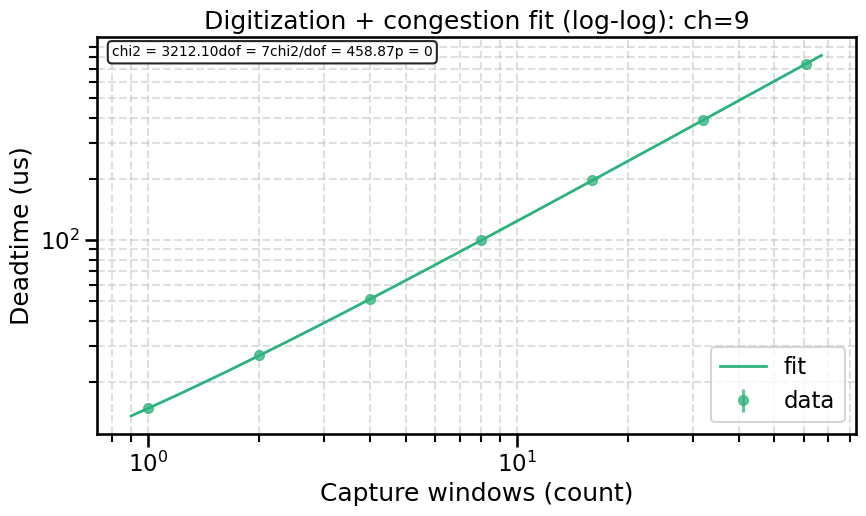

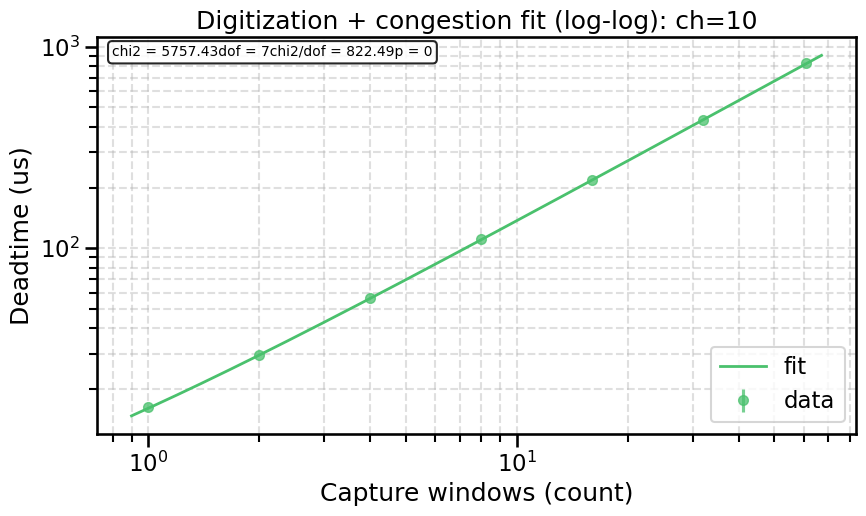

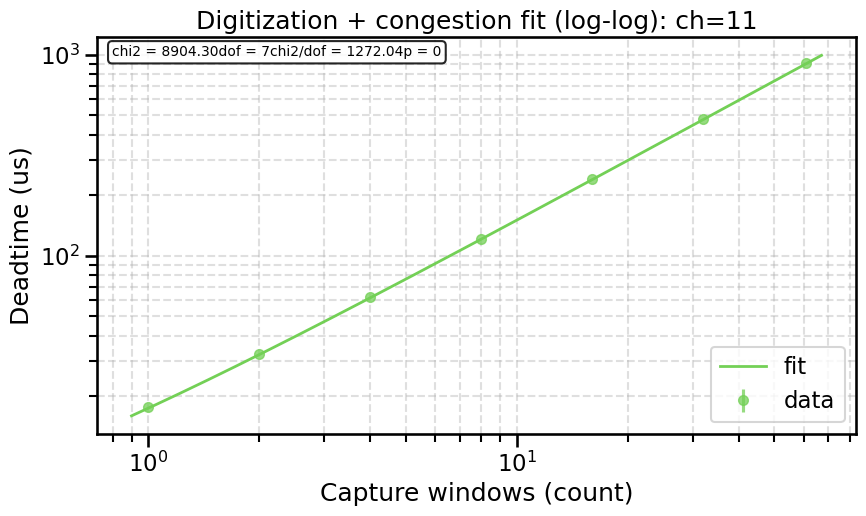

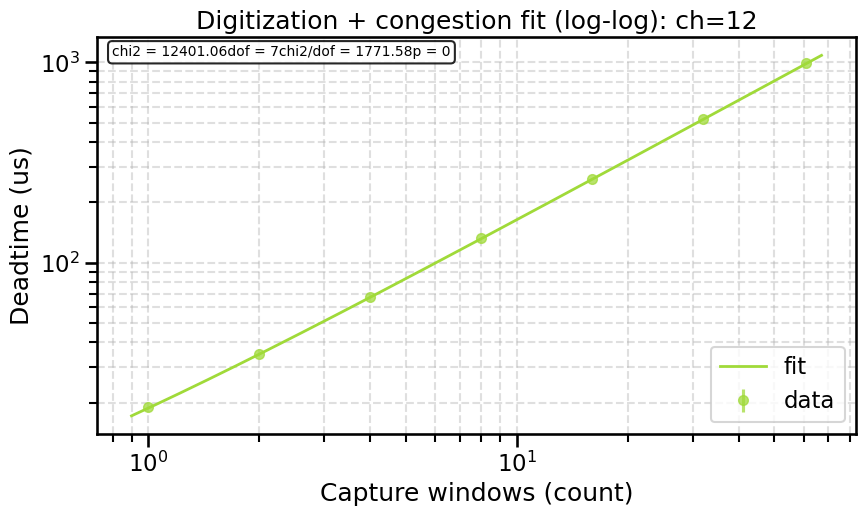

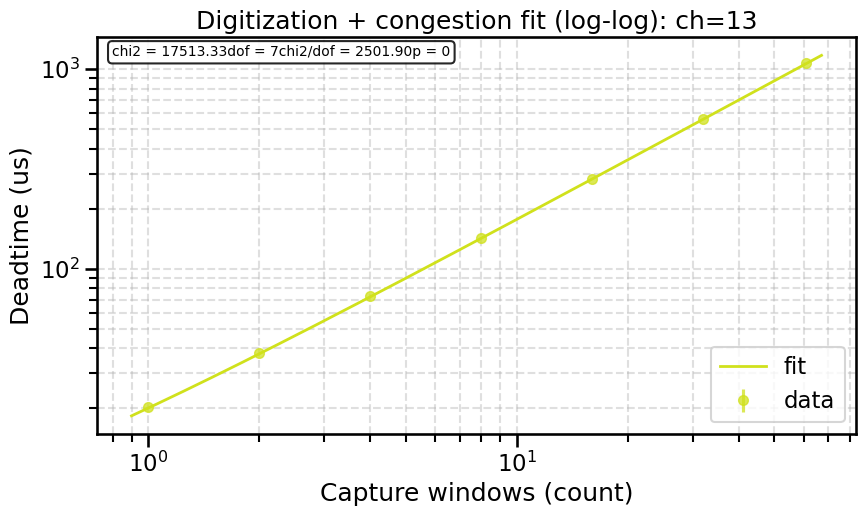

Per-channel chi^2 for global model:
  ch=1: chi2=627528.03, dof=7, chi2/dof=89646.86, p=0
  ch=2: chi2=4093675.46, dof=7, chi2/dof=584810.78, p=0
  ch=3: chi2=77736.30, dof=7, chi2/dof=11105.19, p=0
  ch=4: chi2=35661.24, dof=7, chi2/dof=5094.46, p=0
  ch=5: chi2=8925.84, dof=7, chi2/dof=1275.12, p=0
  ch=6: chi2=41.01, dof=7, chi2/dof=5.86, p=8.07e-07
  ch=7: chi2=359.85, dof=7, chi2/dof=51.41, p=9.59e-74
  ch=8: chi2=1402.58, dof=7, chi2/dof=200.37, p=1.07e-298
  ch=9: chi2=3212.10, dof=7, chi2/dof=458.87, p=0
  ch=10: chi2=5757.43, dof=7, chi2/dof=822.49, p=0
  ch=11: chi2=8904.30, dof=7, chi2/dof=1272.04, p=0
  ch=12: chi2=12401.06, dof=7, chi2/dof=1771.58, p=0
  ch=13: chi2=17513.33, dof=7, chi2/dof=2501.90, p=0


In [3]:

# Global fit with digitization (windows) and congestion (channels*windows) terms
fit_df = df.copy()
w = fit_df['windows'].to_numpy(dtype=float)
ch = fit_df['channel_count'].to_numpy(dtype=float)
y = fit_df['y'].to_numpy(dtype=float)
err_low = fit_df['yerr_low'].to_numpy(dtype=float)
yerr_high_const = 0.008
err_high = np.full_like(y, yerr_high_const)


def fit_digitization_congestion(windows, channels, y_vals, err_low_vals, err_high_vals):
    def residuals(params):
        a, b, c = params
        model = a + b * windows + c * (channels * windows)
        resid = y_vals - model
        sigma = np.where(resid >= 0, err_low_vals, err_high_vals)
        return resid / sigma

    X = np.column_stack([np.ones_like(windows), windows, channels * windows])
    try:
        beta, *_ = np.linalg.lstsq(X, y_vals, rcond=None)
    except np.linalg.LinAlgError:
        beta = np.zeros(3)

    result = least_squares(residuals, x0=beta)
    a, b, c = result.x
    model = a + b * windows + c * (channels * windows)
    resid = y_vals - model
    sigma = np.where(resid >= 0, err_low_vals, err_high_vals)
    chi2_val = np.sum((resid / sigma) ** 2)
    dof = len(y_vals) - 3
    p_val = chi2.sf(chi2_val, dof) if dof > 0 else float('nan')
    a_err = b_err = c_err = float('nan')
    if result.jac.shape[0] >= result.jac.shape[1]:
        try:
            cov = np.linalg.inv(result.jac.T @ result.jac)
            if dof > 0:
                cov = cov * (chi2_val / dof)
            a_err, b_err, c_err = np.sqrt(np.diag(cov))
        except np.linalg.LinAlgError:
            pass
    return (a, b, c), (a_err, b_err, c_err), chi2_val, dof, p_val, resid, sigma


(params, param_errs, chi2_val, dof, p_val, resid, sigma) = fit_digitization_congestion(w, ch, y, err_low, err_high)
(a, b, c) = params
(a_err, b_err, c_err) = param_errs

print('Global fit: y = a + b*windows + c*(channels*windows)')
print(f' a = {a:.6f} ± {a_err:.6f} us (baseline)')
print(f' b = {b:.6f} ± {b_err:.6f} us per window (digitization)')
print(f' c = {c:.6f} ± {c_err:.6f} us per (channel*window) (congestion)')
print(f' chi2 = {chi2_val:.2f}, dof = {dof}, chi2/dof = {chi2_val / dof:.2f}, p = {p_val:.3g}')

channel_values = sorted(fit_df['channel_count'].unique())
palette = sns.color_palette('viridis', n_colors=len(channel_values))
per_channel_stats = []

# Per-channel plots (log-log only)
for color, ch_val in zip(palette, channel_values):
    sub = fit_df[fit_df['channel_count'] == ch_val]
    model_vals = a + b * sub['windows'] + c * (ch_val * sub['windows'])
    resid_ch = sub['y'].to_numpy(dtype=float) - model_vals
    sigma_ch = np.where(resid_ch >= 0, sub['yerr_low'].to_numpy(dtype=float), np.full_like(resid_ch, yerr_high_const))
    chi2_ch = np.sum((resid_ch / sigma_ch) ** 2)
    dof_ch = len(sub)
    p_ch = chi2.sf(chi2_ch, dof_ch) if dof_ch > 0 else float('nan')
    per_channel_stats.append((int(ch_val), chi2_ch, dof_ch, chi2_ch / dof_ch if dof_ch > 0 else float('nan'), p_ch))

    plt.figure(figsize=(9, 5.5))
    plt.errorbar(
        sub['windows'],
        sub['y'],
        yerr=[sub['yerr_low'], np.full(len(sub), yerr_high_const)],
        fmt='o',
        color=color,
        alpha=0.75,
        markersize=7,
        linestyle='none',
        label='data',
    )
    win_grid = np.logspace(
        np.log10(sub['windows'].min() * 0.9),
        np.log10(sub['windows'].max() * 1.1),
        200,
    )
    plt.plot(win_grid, a + b * win_grid + c * (ch_val * win_grid), color=color, linewidth=2, label='fit')

    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Digitization + congestion fit (log-log): ch={int(ch_val)}')
    plt.xlabel('Capture windows (count)')
    plt.ylabel('Deadtime (us)')
    plt.grid(True, linestyle='--', alpha=0.4, which='both')
    stats_text = (
        f'chi2 = {chi2_ch:.2f}'
        f'dof = {dof_ch}'
        f'chi2/dof = {chi2_ch / dof_ch if dof_ch > 0 else float("nan"):.2f}'
        f'p = {p_ch:.3g}'
    )
    plt.text(
        0.02,
        0.98,
        stats_text,
        transform=plt.gca().transAxes,
        ha='left',
        va='top',
        fontsize=10,
        bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.85},
    )
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

print('Per-channel chi^2 for global model:')
for ch_val, chi2_ch, dof_ch, chi2_dof_ch, p_ch in per_channel_stats:
    print(f'  ch={ch_val}: chi2={chi2_ch:.2f}, dof={dof_ch}, chi2/dof={chi2_dof_ch:.2f}, p={p_ch:.3g}')


## Per-pulse fit (optional)


Pulses=2: m=1.346664 ± 0.001604, b=2.894410 ± 0.294960, chi2=5272276.72, dof=89, p=0


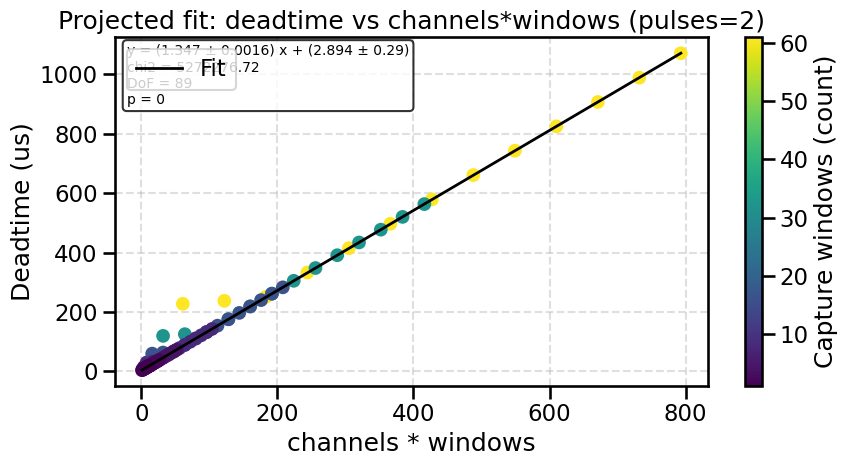

In [4]:
for pulse_count in sorted(df['num_pulses'].dropna().unique()):
    sub = df[df['num_pulses'] == pulse_count]
    if len(sub) < 3:
        continue
    x = sub['x'].to_numpy(dtype=float)
    y = sub['y'].to_numpy(dtype=float)
    yerr_low = sub['yerr_low'].to_numpy(dtype=float)
    yerr_high = np.full_like(y, 0.008)
    m, b, m_err, b_err, chi2_val, dof, p_val = fit_asymmetric(x, y, yerr_low, yerr_high)
    print(f'Pulses={int(pulse_count)}: m={m:.6f} ± {m_err:.6f}, b={b:.6f} ± {b_err:.6f}, chi2={chi2_val:.2f}, dof={dof}, p={p_val:.3g}')
    plt.figure(figsize=(9, 5))
    ax = plt.gca()
    stats_text = (
        f'y = ({m:.4g} ± {m_err:.2g}) x + ({b:.4g} ± {b_err:.2g})\n'
        f'chi2 = {chi2_val:.2f}\nDoF = {dof}\np = {p_val:.3g}'
    )
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, ha='left', va='top', fontsize=10, bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.8})
    plt.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt='none', ecolor='gray', alpha=0.5, zorder=1)
    sc = plt.scatter(x, y, c=sub['windows'], cmap='viridis', s=70, zorder=2)
    x_line = np.linspace(x.min(), x.max(), 200)
    plt.plot(x_line, m * x_line + b, color='black', linewidth=2, label='Fit')
    cbar = plt.colorbar(sc)
    cbar.set_label('Capture windows (count)')
    plt.title(f'Projected fit: deadtime vs channels*windows (pulses={int(pulse_count)})')
    plt.xlabel('channels * windows')
    plt.ylabel('Deadtime (us)')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()
